<a href="https://colab.research.google.com/github/pvgbabu/AWS-Sage-Maker/blob/master/Labs/Lab_2_Naive_RAG_BEHR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Session 2: Building out your first RAG
## Topics:
1. Understanding the data
2. Experiment with different chunking strategies
3. Creating our vector database
4. Create a dataset that we can use to measure our model performance.

**Dataset: Behr technical data sheets.** 137 technical data sheets for BEHR paints, primers and stains.

In [1]:
#@title #Installs, Imports and Global Variables
%%capture
%pip install ipython-autotime
%load_ext autotime
# Every version here is pinned on purpose. An unpinned dependency is a bet that nothing
# upstream changes between now and the moment you run this, and that bet is how a notebook
# that worked last week stops working today.
%pip install -q \
  litellm==1.102.0 "openai>=2.20.0,<3.0.0" \
  llama-index==0.14.24 llama-index-readers-file==0.7.0 fonttools==4.65.0 \
  llama-index-vector-stores-chroma==0.6.0 \
  llama-index-embeddings-litellm==0.6.0 llama-index-llms-litellm==0.8.0 \
  chromadb==1.5.9 pypdf==6.19.0 pymupdf==1.28.2 \
  ipywidgets==7.7.1 pandas==2.2.3 \
  ragas==0.4.3 "langchain-community==0.3.27" "langchain-core<0.4" "langchain-openai<1" datasets==5.0.1


time: 1min 11s (started: 2026-09-21 19:16:36 +00:00)


In [2]:
#@title Imports
import os
import random
import fitz  # PyMuPDF
import io
import pickle
import json
import zipfile
import concurrent.futures

import numpy as np
import pandas as pd

from PIL import Image
from litellm import completion
from llama_index.core import SimpleDirectoryReader
from llama_index.core.ingestion import IngestionPipeline
from llama_index.core.node_parser import SentenceSplitter

from datasets import Dataset

from ragas import evaluate
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

import litellm

litellm.drop_params = True

time: 32.7 s (started: 2026-09-21 19:17:54 +00:00)


/tmp/ipykernel_716/3256508404.py:23: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipykernel_716/3256508404.py:23: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_716/3256508404.py:23: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import (
/tmp/ipykernel_716/3256508404.py:23: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in

In [3]:
# The day's keys come from the workshop hub, so there is nothing to paste and
# nothing to mistype. Rerun this cell any time a key stops working.
# One key covers chat and embeddings, because both go through OpenRouter.
import json, os, urllib.error, urllib.request

WORKSHOP_HUB = "https://tdwi-workshop-hub.vercel.app"

def load_workshop_keys(hub=WORKSHOP_HUB):
    """Ask the hub for the day's keys and load them into this session."""
    request = urllib.request.Request(
        f"{hub}/api/env", data=b"{}", headers={"content-type": "application/json"})
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = json.load(response)
    except urllib.error.HTTPError as error:
        if error.code == 403:
            raise SystemExit(
                "The workshop is not running right now, so the hub is not handing out "
                "keys. If the class is in session, raise your hand and find Nicolas or "
                "Kierra.") from None
        raise SystemExit(
            f"The hub could not hand out a key (error {error.code}). Run this cell again, "
            "and raise your hand if it keeps failing.") from None
    except urllib.error.URLError:
        raise SystemExit(
            "Could not reach the workshop hub. Check that you are on the conference wifi, "
            "then run this cell again.") from None
    os.environ.update(payload)
    return sorted(payload)

print("Loaded from the hub:", ", ".join(load_workshop_keys()))

# Shared settings, fetched rather than retyped. Every lab reads the same file, so the chunk
# size here and the chunk size in Lab 3 cannot drift apart.
import json as _json, urllib.request as _urllib

DATASET = 'behr'   # one notebook per dataset is stamped out at build time; no picker here
_CONFIG_URL = "https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/dataset_config.json"
_urllib.urlretrieve(_CONFIG_URL, "/content/dataset_config.json")
CFG = _json.load(open("/content/dataset_config.json"))
SHARED, DS = CFG['shared'], CFG['datasets'][DATASET]


MODEL = SHARED['litellm_chat_model']      # LiteLLM form, needs the openrouter/ prefix
EMBED_MODEL = SHARED['embed_model']

# Query-time embeddings must use the same model that built the index. A different one
# does not raise, it just quietly retrieves worse.

# Chunking comes from the dataset, not from this cell, so that what you build here matches
# the corpus Lab 3 downloads and the chunk sizes the workshop hub's explorer shows. Behr is
# 1024/200; CalHR is 384/96 because it is a sixth the size and needs finer chunks before
# retrieval has anything to discriminate on.
CHUNK_SIZE = DS['chunk_size']
CHUNK_OVERLAP = DS['chunk_overlap']
print(f"chunking at {CHUNK_SIZE}/{CHUNK_OVERLAP} for {DS['label']}")

DOCS_FOLDER_PATH = "/content/downloaded_pdfs/"

### Source documents, stamped in per dataset by scripts/build_notebooks.py.
### Download TDS documents from github
!wget https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/behr/Data_Resources_TDS.zip

# !unzip /content/Data_Resources_TDS.zip
with zipfile.ZipFile('/content/Data_Resources_TDS.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


Loaded from the hub: OPENROUTER_API_KEY
chunking at 1024/200 for Behr technical data sheets
--2026-09-21 19:18:31--  https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/behr/Data_Resources_TDS.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15542995 (15M) [application/zip]
Saving to: ‘Data_Resources_TDS.zip’

Data_Resources_TDS. 100%[===================>]  14.82M  --.-KB/s    in 0.1s    

2026-09-21 19:18:32 (149 MB/s) - ‘Data_Resources_TDS.zip’ saved [15542995/15542995]

time: 1.18 s (started: 2026-09-21 19:18:31 +00:00)


____
## 1. Understanding the data
For this hands-on session, we will be focusing on using product data sheets of products for BEHR paint. Our focus is to help create a natural-language Question-Ansering interface that will allow us to query and cite our information appropriately without the need to search for the right document.

With any problem, it is critical for us to view the data being inputted in the model to better understand.

In [4]:
from IPython.display import display, clear_output
from ipywidgets import Button, Output, VBox, Layout
import fitz
from PIL import Image
import io
import random
import os

def get_random_pdf_image():
    """Opens a random PDF from the DOCS_FOLDER_PATH and returns the first page as a PIL Image."""
    pdf_files = [f for f in os.listdir(DOCS_FOLDER_PATH) if f.endswith('.pdf')]
    if not pdf_files:
        return None

    sample_pdf = os.path.join(DOCS_FOLDER_PATH, random.choice(pdf_files))
    pdf_document = fitz.open(sample_pdf)
    page = pdf_document.load_page(0)
    pix = page.get_pixmap()
    img = Image.open(io.BytesIO(pix.tobytes()))
    pdf_document.close()
    return img

# Create output area
output = Output()

# Create button with larger size
button = Button(
    description="Click to Show New PDF",
    layout=Layout(
        width='250px',      # Button width
        height='70px'       # Button height
    ),
    style={
        'button_color': 'yellow',   # Yellow color
        'font_weight': 'bold',   # Bold text
    }
)

def show_random_pdf():
    """Display a random PDF image"""
    with output:
        clear_output(wait=True)
        img = get_random_pdf_image()
        if img:
            display(img)
        else:
            print("No PDF found")

# Set up button click handler
button.on_click(lambda b: show_random_pdf())

# Show initial PDF on first run
show_random_pdf()

# Display the button and output area
display(VBox([button, output]))

time: 210 ms (started: 2026-09-21 19:18:46 +00:00)


The above PDF is an example of 1 of 137 BEHR Technical Data Sheets (TDS). As we can see, it includes information such as
Product Information, Recommended Uses, Product Specifications, etc.


I want to note that, visually, this TDS layout is very clear to a human reader. It has distinct subsections and tables with information that allows us to quickly pinpoint where in the document we need to look to answer any questions we may have about the product. That being said, we will learn that translating this information to be easy and accessible for our RAG solution is more complex. We will go over specific solutions to this in our next lab. For now, we can focus on using simpler chunking/embedding methogologies to set up our baseline.

____
## Brief aside: Business Relevance

When integrating data into your RAG solution, ensure it's tied to your business problem. For BEHR, TDS sheets are crucial as they cover various scenarios, such as:
- **Product Usage Questions:** "What are the recommended uses for a particular stain?"
- **Application Guidance:** "What tools do I need?"
- **Safety Precautions:** "What should I do if the stain is ingested?"

By incorporating these documents, we can enhance customer support and provide quick and accurate information.

**I challenge anyone building out a RAG solution to have a clear idea of the questions that solution is hoping to answer. This exercise will allow you to not only filter the necessary data to use in the solution, but to help justify where the solution is delivering value to the business.**



Okay, now back to building out first RAG pipeline!
_____

To start, we will experiment with a few simple chunking strategies to help create our first vector store.

## Instructions:
1. Open the **Chunking** page on the workshop hub: https://tdwi-workshop-hub.vercel.app/chunking
2. Try both splitters, move the chunk size and overlap, and compare the results against the same document.

🤔 Do you notice any issues with the documents and the chunks being displayed? If you were assigned a task that relied on this data, but were provided only the chunk of text information and not the pdf itself, would you be able to make sense of it?
---

* * *
### The chunking explorer lives on the workshop hub

Open https://tdwi-workshop-hub.vercel.app/chunking in a second tab. It runs the same two
splitters, `SentenceSplitter` and `TokenTextSplitter`, over the same documents you are about
to index, and it offers both corpora. Nothing to install and nothing to launch, so a broken
cell here cannot cost you the exercise.

Leave it open. You will want it again in Lab 3, when the chunk size stops being a setting
you picked and starts being a number you can defend.


____

As we can see, the chunks created from the technical data sheets do not seem to accurately represent the information being displayed. To start, we will use the SentenceSplitter as our more naive approach in order to measure the improvements of more advanced techniques in the next hands-on session.


The following code will go through each of our PDFs and chunk their information into a vector database. In this example, we will use simply use llama index with an ephemeral chromadb. Note: There are many ways to store the data, and it is important to understand the pros/cons of each when deciding which to use in production. In particular, if your system uses postgres, you may be better suited sticking to using pgvector versus having to maintain a new database altogether. We will also use llama_index ingestion pipelines to run a job that embeds each chunk into our dataframe.
In addition, we will use the text-embedding-3-small embedding model (https://platform.openai.com/docs/guides/embeddings).

In [5]:
from llama_index.core import VectorStoreIndex
from llama_index.vector_stores.chroma import ChromaVectorStore
from IPython.display import Markdown, display
from llama_index.embeddings.litellm import LiteLLMEmbedding

import chromadb

from llama_index.core import Settings

# Set the embedding model globally, before any index is built.
# Without this, VectorStoreIndex falls back to Settings.embed_model, which defaults to
# OpenAI and needs an OPENAI_API_KEY we deliberately no longer have. Worse, when that key
# IS present, retrieval quietly runs on a different model than the one that built the
# index, and nothing raises. The same model on both sides, or the numbers are fiction.
Settings.embed_model = LiteLLMEmbedding(model_name=EMBED_MODEL, embed_batch_size=100)


time: 2.93 s (started: 2026-09-21 19:19:13 +00:00)


In [6]:
#@title Data ingestion pipeline (about 1-3 minutes)

## Step 0. Initialize chromadb
chroma_client = chromadb.EphemeralClient()
chroma_collection = chroma_client.get_or_create_collection(
                    name="initial_collection",
                    configuration={"hnsw": {"space": "cosine"}}
                )
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

## Step 1. Use llama-index to create a DirectoryReader
# 137 PDFs, one document per page. If this prints far fewer documents than pages,
# llama-index-readers-file is missing and the text you get back will be junk.
documents = SimpleDirectoryReader(DOCS_FOLDER_PATH).load_data(num_workers=-2)
print(f"Loaded {len(documents)} pages from {DOCS_FOLDER_PATH}")

## Step 2. Chunk and embed.
# embed_batch_size matters more than it looks: the default of 10 sends ~200 separate
# requests for this corpus. Batching at 100 cuts the wall time by about 4x.
pipeline = IngestionPipeline(
    transformations=[SentenceSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP),
                     LiteLLMEmbedding(model_name=EMBED_MODEL, embed_batch_size=100)
                     ])
nodes = pipeline.run(documents=documents, num_workers=-2, show_progress=True)

## Step 3. Write to Chroma in batches.
# Chroma refuses a single .add() larger than 5461 records. This corpus is under that,
# but a bigger one would fail at the very end of a long, expensive cell.
BATCH = 4000
for i in range(0, len(nodes), BATCH):
    vector_store.add(nodes[i:i + BATCH])

## Step 4. Say out loud what landed, so an empty index cannot masquerade as a working one.
count = chroma_collection.count()
print(f"Indexed {count} chunks from {len(documents)} pages")
assert count > 0, "Nothing was indexed. Re-run this cell before continuing; every answer below would be invented."


Loaded 256 pages from /content/downloaded_pdfs/


Applying transformations:   0%|          | 0/2 [00:00<?, ?it/s]

Indexed 468 chunks from 256 pages
time: 53.5 s (started: 2026-09-21 19:19:22 +00:00)


In [7]:
# embed_model is passed explicitly as well as set globally above. Queries have to be
# embedded by the same model that embedded the corpus.
index = VectorStoreIndex.from_vector_store(vector_store, embed_model=Settings.embed_model)


time: 2.35 ms (started: 2026-09-21 19:21:00 +00:00)


In [8]:
from llama_index.core.prompts import RichPromptTemplate

retriever = index.as_retriever(similarity_top_k=5)

template_str = """We have provided context information below.
---------------------
{{ context_str }}
---------------------
Given this information, please answer the question: {{ query_str }}
"""

qa_template = RichPromptTemplate(template_str)

query_str = "what should I use to paint my garage floor?" #@param {"type": "string"}

nodes = retriever.retrieve(query_str)
context_str = "\n\n".join([n.node.get_content() for n in nodes])
messages_chat = [
            {"content": qa_template.format(context_str=context_str, query_str=query_str), "role": "user"}
        ]
response = completion(model=MODEL, messages=messages_chat, temperature=1, stream=False)
response_text = response.choices[0].message.content
display(Markdown(f"**RESPONSE:**\n\n{response_text}"))

### Sources used in the response:
for i, node in enumerate(nodes):
  display(Markdown(f"**Source {i+1}: {node.node.metadata['file_name']} -> Similarity Score = {node.score:.2f}**"))
  display(Markdown(node.node.text))

**RESPONSE:**

Based on the provided information, you should use the "INTERIOR/EXTERIOR CONCRETE & GARAGE 1-PART EPOXY COATING NO. 900 WHITE BASE" for painting your garage floor. This product is a high-performance, water-based epoxy coating specifically designed for concrete surfaces like garage floors. It resists hot tire pickup, marring, chemicals, oil, gasoline, scuffing, fading, cracking, peeling, and blistering, making it suitable for garage floors.

**Important notes for application:**
- Properly prepare the surface by cleaning and etching the concrete.
- Use a primer coat such as BEHR PREMIUM® Concrete & Garage 1-Part Epoxy Coating or No. 880 Bonding Primer.
- Follow the recommended application methods (brush, roller, or airless spray).
- Allow sufficient drying time before subjecting the floor to heavy traffic or automobile tires (generally 7 days).

Avoid using products not suitable for vehicular traffic or designed for industrial applications, as well as following proper surface preparation procedures for durability.

**Source 1: 900_TDS_US.pdf -> Similarity Score = 0.66**

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
INTERIOR/EXTERIOR  
CONCRETE & GARAGE 1-PART EPOXY COATING
NO. 900 WHITE BASE
PRODUCT INFORMATION
A high-performance, ready-to-use water-based coating that is designed to resist hot tire pickup and marring. This self-priming satin  
finish is resistant to household-type chemicals, oil and gasoline, which reduces the need for maintenance of hard-to-clean interior or  
exterior floors. This durable coating also resists scuffing, fading, cracking, peeling and blistering.
RECOMMENDED USES:
Use on properly prepared interior or exterior horizontal concrete surfaces such as: Garage Floors, Driveways, Basement Floors, 
Porches and Pool Decks. NOT for industrial applications, such as areas subject to fork lifts.
COMPLIES WITH THE BELOW AS OF 3/1/2020
SCAQMD YES OTC YES
CARB SCM 2007 YES LADCO YES
OTC Phase II YES AIM YES
PRODUCT SPECIFICATIONS:
Tint Bases/Max Tint Load:
No. 900 White Base 122 fl oz / 8 fl oz 
No. 930 Deep Base 116 fl oz / 14 fl oz
Pre-mixed Colors:
No. 901 Silver Gray 
No. 902 Slate Gray
Gloss: 10-20 @ 60°
Resin Type: Acrylic/Epoxy 
Weight per Gallon: 10.2 lb
% Solids by Volume: 32% ± 2% 
% Solids by Weight: 44% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 75-85 KU (after tinting)
Recommended Film Thickness:  
 Wet: 5.3 mils / Dry: 1.6 mils @ 300 sq ft/gal  
 W et: 3.2 mils / Dry: 1.0 mils @ 500 sq ft/gal
Coverage: 300-500 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.
APPLICATION:
Brush: Nylon/polyester
Roller: 3/8” – 1/2” nap roller cover, depending on surface 
texture
Airless Spray:  
 Tip: .015”- .021” 
 Filter: 60 mesh
 Fluid Pressure:  1,400 - 2,400 psi 
Thinning: Do Not Thin. 
Dry Time: @ 77°F & 50% RH
To Touch: 1 hour
Recoat: 4 to 6 hours 
Dry times are temperature, humidity, and film thickness
dependent. The floor may be subjected to light foot
traffic after 24 hours. Allow surface to dry 72 hours
before subjecting to heavy foot traffic or repositioning
furniture. Allow 7 days before subjecting painted surface 
to automobile tires. Apply an additional coat for optimal 
hide and durability.
SURFACE PREPARATION:
New and Uncoated Concrete or Masonry Surfaces: 
New concrete must cure for a minimum of 30 days.  
For proper penetration and adhesion of topcoat, use a 
product such as a muriatic acid to clean and etch the surface. 
Follow all label instructions. Apply a Primer Coat: Apply 1 
coat of BEHR PREMIUM® Concrete & Garage 1-Part Epoxy 
Coating or a product such as BEHR PREMIUM Concrete & 
Masonry Bonding Primer No. 880 to increase adhesion of 
topcoat to the surface.
Painted, Stained or Sealed Concrete: For a painted 
surface in sound condition, use a product to clean and 
prepare the surface. If the coating is failing or peeling,  
use a paint stripper to remove old coating or scrape/sand 
down to a sound concrete surface. Scuffsand glossy surfaces. 
Clean and spot-etch any exposed concrete. Remove all dust 
with a damp cloth, allow to dry. Spot-prime all bare concrete 
areas with BEHR PREMIUM Concrete & Garage 1-Part Epoxy 
Coating or with a product such as BEHR PREMIUM No. 880 
Concrete & Masonry Bonding Primer to increase adhesion of 
topcoat to the surface.
WARNING! If you scrape, sand or remove old paint, you 
may release lead dust. LEAD IS TOXIC. EXPOSURE TO LEAD 
DUST CAN CAUSE SERIOUS ILLNESS, SUCH AS BRAIN DAMAGE, 
ESPECIALLY IN CHILDREN.

**Source 2: 6050-N_TDS_US.pdf -> Similarity Score = 0.63**

TECHNICAL DATA SHEET
This information is provided "as is" and no representations or warranties, either expressed or implied, of merchantability, fitness for a particular purpose or of any other  
nature are made with respect to this information or to any product referred to in this information. For SDS or to consult with a Behr Certified Coatings Professional,  
call 1-800-854-0133 Ext. 2 (U.S.A. only). ©2017 Behr Process Corporation Santa Ana, CA 92704 U.S.A.  Revised 6/2017
1 of 2
PORCH & PATIO FLOOR PAINT
NO. 6050-N (LOW-LUSTRE) ULTRA PURE WHITE®
PRODUCT INFORMATION
BEHR PREMIUM® Porch & Patio Floor Paint is available in two sheens, Low-Lustre and Gloss Enamels. This l00% acrylic latex 
product , has a mildew resistant finish, resists scuffing, fading, cracking and peeling while providing a durable, long-lasting  
finish that is ideal for both interior and exterior applications. 
RECOMMENDED USES:
This product is ideal for porches, floors, decks, basements, patios, siding, trim, furniture and trellises. Not for use on garage floors 
or areas subject to automotive traffic. Use on previously painted or primed interior or exterior surfaces such as:  
• Wood          • Concrete          • Composite
PRODUCT SPECIFICATIONS:
Tint Bases/Max Tint Load:  
No. 6050-N Ultra Pure White® 128 oz. / 2 oz.
No. 6400 Medium Base 120 oz. / 10 oz.
No. 6300 Deep Base 116 oz. / 14 oz.
PRE-MIXED COLORS:  
No. 6694 Low-Lustre Silver Gray  
No. 6695 Low-Lustre Slate Gray
Gloss: 5-15 @ 60°  
Sheen: 5-15 @ 85°
Resin Type: 100% Acrylic Latex
Weight per Gallon: 10.7 lbs.
% Solids by Volume: 37% 
% Solids by Weight: 49.9% 
VOC: <50 g/L
Flash Point: N/A
Viscosity: 90 -100 KU
Recommended Film Thickness:
Wet: 8.0 Dry: 2.9 mils @ 200 Sq. Ft./Gal. 
Wet: 4.0 Dry: 1.4 mils @ 400 Sq. Ft./Gal. 
Coverage: 200-400 Sq.Ft./Gal. depending on application 
method and substrate porosity. Does not include the loss  
of material from spraying.
APPLICATION:
Brush: Nylon/polyester
Roller: 3/8"-1/2" nap 
Airless Spray:  At packaged consistency
Tip: .015"- .019"
Filter: 60 mesh
Thinning: (If required) No more than 1/2 pint  
of water per gallon.
Dry Time: @ 77° & 50% RH
Longer dry time may be required in cooler temperatures  
and higher humidity.
To Touch: 1 hour
To Recoat: 4-6 hours
Full Cure: 2 weeks. Allow 72 hours before subjecting 
to normal use. After 30 days, cured paint film may be 
cleansed with a mild, non-abrasive liquid detergent.
SURFACE PREPARATION:
All surfaces must be clean, free of dust, chalk, oil, grease, 
wax, polish, mold and mildew stains, loose and peeling  
paint, rust and all other foreign substances.
Non-Ferrous Metal: The oil film on new non-ferrous metal 
must be removed before it is painted. Remove oil film with 
a detergent and water solution. For better paint adhesion, 
sand the surface with sandpaper, steel wool, or by scrubbing 
the surface with a detergent and water solution, followed by 
a thorough rinsing with clean water.
New Surfaces:  Wipe down clean metal surfaces prior to 
painting with a vinegar solution, one part vinegar to five 
parts water (1:5). Bare metal must be primed the same day 
it is cleaned. Metal: Remove all rust and mill scale using 
sandpaper, steel wool, abrasive blasting, or other abrading 
methods to create a profile on the metal’s surface. Clean the 
metal by scrubbing the surface with a detergent and water 
solution, followed by a thorough rinsing with clean water.

**Source 3: 6250_TDS_US.pdf -> Similarity Score = 0.63**

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PORCH & PATIO ANTI-SLIP FLOOR PAINT
NO. 6250 (TEXTURED LOW-LUSTRE) ULTRA PURE WHITE ®
PRODUCT INFORMATION
BEHR PREMIUM® Porch & Patio Anti-Slip Floor Paint is a 100% acrylic textured low-lustre enamel that is ideal for interior/exterior 
applications on wood and concrete porches, patios, pool decks and walkways. It provides a mildew resistant paint finish that 
resists cracking and peeling, as well as withstands scuffing and fading.
RECOMMENDED USES:
This product is ideal for porches, floors, decks, basements, patios, siding, trim, furniture and trellises. Not for use on garage 
floors or areas subject to automotive traffic or hydrostatic pressure. Use on properly prepared, uncoated, previously painted or 
primed interior or exterior surfaces such as:
• Wood • Conc rete • Comp osite Wood 
COMPLIES WITH THE BELOW AS OF 6/1/2022
SCAQMD YES OTC YES
CARB SCM 2007 YES LADCO YES
OTC PHASE ll YES AIM YES
PRODUCT SPECIFICATIONS:
Tint Bases/Max Tint Load:  
No. 6250 Ultra Pure White® 128 fl oz / 2 fl oz 
No. 6230 Deep Base 116 fl oz / 14 fl oz 
PRE-MIXED COLORS: 
No. 6295 Slate Gray
No. 6294 Silver Gray
Gloss: 0 – 5 @ 60°
Sheen: 0 – 5 @ 85°
Resin Type: 100% Acrylic
Weight per Gallon: 12.5 lb
% Solids by Volume: 48% ± 2% 
% Solids by Weight: 64% ± 2%
VOC: <50 g/L
Flash Point: N/A
Viscosity: 115 – 130 KU
Recommended Film Thickness:
Wet: 21.3 Dry: 10.2 mils @ 75 sq ft/gal
Wet: 10.7 Dry: 5.1 mils @ 150 sq ft/gal
Coverage: 75 – 150 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.
APPLICATION:
Brush: Nylon/polyester
Roller: 1/4" – 3/8" nap roller, depending on surface texture
Spray: Texture sprayer capable of 1 gpm with a 3 mm tip.  
Do not use with airless sprayer.
Thinning: Do not thin if using a roller or brush; however, if 
using a sprayer and thinning is required, thin with water at a 
rate of no more than 1/2 pint per gallon.
Dry Time: @77°F & 50% RH
To Touch: 2 hours 
To Recoat: 4 – 6 hours
Dry times are temperature, humidity, and film thickness
dependent.
SURFACE PREPARATION:
New or Weathered Wood: Use a product such as BEHR 
PREMIUM® No. 63 All-In-One Wood Cleaner. Lightly sand to 
remove remaining wood fibers/fuzz. 
Note: WARNING! Sanding or scraping pressure treated 
lumber may be hazardous; wear appropriate protection.
Painted Surfaces-Wood:  For a painted surface in sound 
condition, use a product to clean and prepare the surface. 
If the coating is failing or peeling, use a paint stripper to 
remove old coating. Scuff sand glossy surfaces. Use stainless 
steel or galvanized nails to prevent nail staining. Countersink 
nail heads, repair imperfections and sand smooth. Remove 
all dust with a damp cloth, allow to dry.
Uncoated Concrete or Masonry Surfaces: Allow new 
surfaces to cure 30 days. Clean and etch surface using a 
product such as a muriatic acid etcher (read and follow all 
manufacturer’s label directions) to achieve a textured profile 
similar to 150 grit sandpaper. Wipe your fingers over the 
clean, dry floor to check for dust or powder. Ensure there 
is no residue on your fingers that may have been left from 
the etcher. If residue is found, rinse the surface to remove 
residue. Allow the surface to dry completely. Sprinkle a few 
drops of water onto the surface.

**Source 4: 6705_TDS_US.pdf -> Similarity Score = 0.62**

436 
2 coats BEHR PREMIUM Porch & Patio Floor Paint
Vinyl Siding, Architectural Plastics:
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM Porch & Patio Floor Paint
CLEAN-UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water. Do 
not dispose of this product down a drain. If spilled, contain 
material and remove with an inert absorbent. Dispose of 
contaminated absorbent, container and unused product 
in accordance with all current federal, state and local 
regulations. For recycling or disposal of empty containers, 
unused product and soiled rags, contact your household 
refuse collection service.
CAUTIONS/LIMITATIONS:
• Protect from freezing.
• Do not use on garage floors and driveways.
• Do not use on roofs.
• For best results, apply when air, material and surface 
temperatures are between 50°F and 90°F. Do not apply in 
direct sunlight. Temperatures above 90°F can cause the 
paint to dry too fast, whereas temperatures below 50°F 
can inhibit proper film formation. NOTE: If the surface is 
hot to the touch it should be considered too hot to apply 
this coating.
• Allow 72 hours before subjecting to normal use.
• After 30 days, cured paint film may be cleaned with a mild, 
non-abrasive liquid detergent.
• Shelf life under normal conditions is two years unopened.
GENERAL INFORMATION:
WARNING IRRITANT HARMFUL IF SWALLOWED. 
CONTAINS: ETHYLENE GLYCOL. MAY CAUSE EYE, NOSE AND 
THROAT IRRITATION. AVOID CONTACT WITH SKIN AND EYES 
AND AVOID BREATHING OF VAPORS AND SPRAY MIST. WEAR 
EYE PROTECTION AND PROTECTIVE CLOTHING. USE ONLY WITH 
ADEQUATE VENTILATION. To avoid breathing vapors and 
spray mist, open windows and doors or use other means to 
ensure fresh air entry during application and drying. If you 
experience eye watering, headaches or dizziness, increase 
fresh air. If properly used, a respirator (NIOSH approved for 
organic vapor with P series particulate pre-filter) may offer 
additional protection; obtain professional advice before 
using. A dust mask does not provide protection against 
vapors. Avoid contact with eyes and skin. Wash thoroughly 
after handling. Close container after each use.
FIRST AID: If you experience difficulty in breathing, 
leave the area to obtain fresh air. If continued difficulty is 
experienced, get medical assistance immediately. In case of 
eye contact, flush immediately with plenty of water for at 
least 20 minutes and get medical attention; for skin, wash 
thoroughly with soap and water. If swallowed, get medical 
attention immediately.
KEEP OUT OF REACH OF CHILDREN – DO NOT TAKE 
INTERNALLY.
PORCH & PATIO FLOOR PAINT GLOSS ENAMEL
NO. 6705 ULTRA PURE WHITE®

**Source 5: 6705_TDS_US.pdf -> Similarity Score = 0.62**

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
This information is provided “as is” and no representations or warranties, either express or implied, of merchantability, fitness for a particular purpose or of any other 
nature are made with respect to this information or to any product referred to in this information. For SDS or to consult with a Behr Paint Company representative,  
call 1-800-854-0133 Ext. 2 (U.S.A. only). ©2020 Behr Process Corporation, Santa Ana, CA 92705 U.S.A. Revised 6/2020
1 of 2
PORCH & PATIO FLOOR PAINT GLOSS ENAMEL
NO. 6705 ULTRA PURE WHITE®
PRODUCT INFORMATION
BEHR PREMIUM® Porch & Patio Floor Paint is available in two sheens, Low-Lustre and Gloss Enamels. This 100% acrylic latex 
product has a mildew resistant finish, resists scuffing, fading, cracking and peeling while providing a durable, long-lasting finish 
that is ideal for both interior and exterior applications. 
RECOMMENDED USES:
This product is ideal for porches, floors, decks, basements, patios, siding, trim, furniture and trellises. Not for use on garage floors 
or areas subject to automotive traffic. Use on previously painted or primed interior or exterior surfaces such as:  
• Wood          • Concrete          • Composite
PRODUCT SPECIFICATIONS:
Tint Bases/Max Tint Load:  
No. 6705 Ultra Pure White 128 fl oz / 2 fl oz
No. 6730 Deep Base 116 fl oz /14 fl oz
PRE-MIXED COLORS:  
No. 6795 Slate Gray
Gloss: 65+ @ 60°
Resin Type: 100% Acrylic Latex
Weight per Gallon: 10.4 lb
% Solids by Volume: 34% ± 2% 
% Solids by Weight: 48% ± 2% 
VOC: < 100 g/L
Flash Point: N/A
Viscosity: 95 – 100 KU
Recommended Film Thickness:
Wet: 8.0 mils / Dry: 2.8 mils @ 200 sq ft/gal 
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal 
Coverage: 200 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.
APPLICATION:
Brush: Nylon/polyester
Roller: 3/8" – 1/2" nap roller cover, depending on surface 
texture 
Airless Spray:  
Tip: .015" – .021"
Filter: 60 mesh
Thinning: If required, thin with water at a rate of no more 
than 1/2 pint per gallon.
Dry Time: @ 77°F & 50% RH
Longer dry time may be required in cooler temperatures  
and higher humidity.
To Touch: 1 hour
To Recoat: 4 – 6 hours
Full Cure: 2 weeks. Allow 72 hours before subjecting 
to normal use. After 30 days, cured paint film may be 
cleansed with a mild, non-abrasive liquid detergent.
SURFACE PREPARATION:
All surfaces must be clean, free of dust, chalk, oil, grease, 
wax, polish, mold and mildew stains, loose and peeling 
paint, rust and all other foreign substances.
Drywall:  All drywall surfaces should be sufficiently sanded 
smooth. Remove any remaining drywall dust prior to 
priming. Allow all drywall compounds to be completely dry 
prior to coating. 
Wood: Remove mill glaze with sandpaper or use a product 
such as BEHR PREMIUM® All-In-One Wood Cleaner No. 63 
(exterior only) to open the pores of the wood and follow all 
label instructions. For severe stains caused by mold, mildew, 
algae and fungus, apply a mildew stain removing product. 
Set nails and fill holes, scratches, and gouges with the 
appropriate wood filler and let dry completely. Remove all 
dust with a wiping cloth.  Fill all gaps with a 100% acrylic, 
siliconized, paintable caulking and allow to dry completely. 
Patched and filled surfaces should be sanded smooth 
and dusted clean prior to coating. WARNING! Sanding or 
scraping pressure treated lumber may be hazardous; wear 
appropriate protection.

time: 3.57 s (started: 2026-09-21 19:21:03 +00:00)


____
Now that we have created/loaded in our vector store, we can create our query engine. To start, we will simply extract the top 5 documents

____
## Congrats on creating your first RAG QA Agent 🎉

Feel free to experiment with different questions above! In particular, take a look at a pdf and try to see how well it retrieves the correct information.

**Questions to try.** Paste any of these into `query_str` above and re-run the cell.

* What is the dry-to-touch time for BEHR MARQUEE interior paint?
* How should I prepare a previously painted exterior wood surface?
* What spread rate should I expect per gallon on a smooth surface?
* How many coats are recommended over bare masonry?
* What should I do if the stain is swallowed?

Watch the sources printed under each answer as much as the answer itself. A confident answer built from the wrong data sheet is the failure this lab is teaching you to see.

stop.svg

**STOP** - end of LAB 2-A


---



## LAB 2-B: Evaluation

### Importance of Metric-Driven Experimentation in Developing a RAG System
There are many ways to measure the success of a RAG system, and metric-driven experimentation is a crucial part of this process. While user testing is essential, it doesn't scale well for rapid experimentation. Other effective methods include using metrics from tools like ragas (https://github.com/explodinggradients/ragas) and creating a golden dataset with questions, context, and answers. Though a perfect golden dataset is rarely available, generating your own version with context-specific questions and answers can provide valuable insights. This approach allows us to objectively evaluate and compare different strategies, ensuring we make meaningful improvements to the system efficiently.


If you are interested in understanding how I created this sample dataset, please refer to the synthetic dataset documentation for RAG here: https://deepeval.com/docs/golden-synthesizer


In [ ]:
# The golden set URL comes from the dataset config fetched at the top of this notebook.
_urllib.urlretrieve(DS['golden_url'], "/content/Golden_Test_Data_DeepEval.csv")


In [ ]:
golden_df = pd.read_csv('/content/Golden_Test_Data_DeepEval.csv')
golden_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
print(golden_df.shape)
print("Example inputs and expected_outputs from the golden dataset:",end='\n\n')
for example in golden_df.sample(3)[['input', 'expected_output']].values:
  print(f"Input: {example[0]}")
  print(f"Expected Output: {example[1]}", end='\n\n')

(240, 11)
Example inputs and expected_outputs from the golden dataset:

Input: How do the recommended types of eye protection compare in effectiveness for paint application safety?
Expected Output: The context does not specify different types of eye protection or their comparative effectiveness for paint application safety. It simply states that eye protection is recommended and emphasizes avoiding contact with eyes. For specific comparisons, consult safety guidelines or product information related to eye protection.

Input: What details does the technical data sheet include regarding the mildew resistance of BEHR PRO e600 Exterior Semi-Gloss Paint?
Expected Output: The technical data sheet states that BEHR PRO e600 Exterior Semi-Gloss Paint provides a highly uniform, mildew-resistant finish, making it suitable for exterior applications.

Input: Identify the ideal primer for superior corrosion resistance on ferrous and non-ferrous metals.
Expected Output: The ideal primer for superior 

Now that we have loaded our questions, we are ready to start running some metric-driven experimentation! For now, let us limit the first pass to a small random sample of questions to serve as a gutcheck of how well our RAG QA system performs.

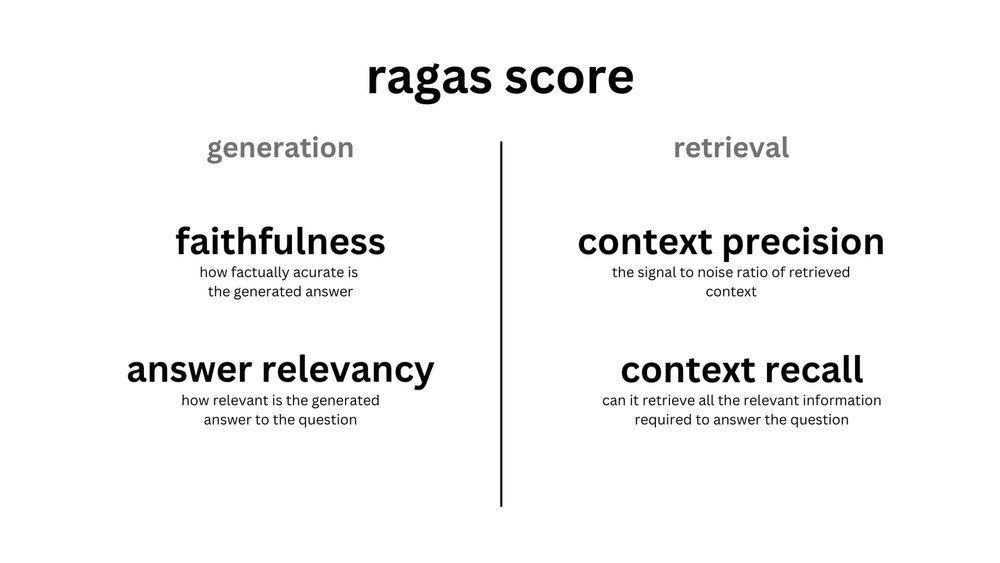


In [ ]:
from tqdm import tqdm

# Sample size and seed come from the shared config, not from this cell: whatever
# lab_sample_size says there is what every lab runs, so Lab 2 and Lab 3 are measuring
# the same questions. It is set large enough to see the pattern and small enough to
# finish inside the time box. The seed is fixed so that your numbers and your
# neighbour's are comparable.
N_QUESTIONS = SHARED['lab_sample_size']
sample_test_df = golden_df.sample(N_QUESTIONS, random_state=SHARED['random_state']).reset_index(drop=True)
print(f"answering {N_QUESTIONS} golden questions with {MODEL}")

output = []

def process_question(row):
    """Processes a single question and returns the required output format."""
    temp_info = {'question': row['input']}
    temp_info['ground_truth'] = row['expected_output']
    nodes = retriever.retrieve(row['input'])
    context_str = "\n\n".join([n.node.get_content() for n in nodes])
    messages_chat = [
                {"content": qa_template.format(context_str=context_str, query_str=row['input']), "role": "user"}
            ]

    # MODEL is the LiteLLM form from the shared config. Lab 2 uses the cheaper model on
    # purpose: it fires more calls per attendee than any other lab.
    response = completion(model=MODEL, messages=messages_chat, temperature=1, stream=False)
    response_text = response.choices[0].message.content
    temp_info['answer'] = response_text # Convert response object to string
    temp_info['contexts'] = [node.node.text for node in nodes]
    return temp_info


for _, row in tqdm(sample_test_df.iterrows(), total=sample_test_df.shape[0]):
    output.append(process_question(row))


sample_test_df = pd.DataFrame(output)

100%|██████████| 25/25 [02:43<00:00,  6.55s/it]

time: 2min 43s (started: 2025-11-24 19:08:33 +00:00)


In [ ]:
sample_test_df.sample(5)

,question,ground_truth,answer,contexts
15,Outline the necessary sequential actions for e...,"To effectively prepare surfaces for painting, ...",Effective surface preparation is crucial for o...,[Forward) \nResult: > 100 in-lb\nBlock Resis...
5,Imagine a scenario where a new building materi...,The Urethane Alkyd Semi-Gloss Enamel is design...,"Based on the provided context, there is no men...","[Set nails and fill holes, scratches, and goug..."
19,What are the specific dry times for paint at 7...,"At 77°F and 50% relative humidity, the specifi...","I apologize, but the provided context informat...","[WARNING! If you scrape, sand or remove old pa..."
13,How does the cleanup process for a paint spill...,The cleanup process for a paint spill involves...,"Based on the provided context, there is **insu...",[CAUSES EYE AND SKIN IRRITATION. \nMAY CAUSE R...
2,Outline emergency protocols for handling hazar...,"In domestic settings with children, follow the...","Based on the provided context information, her...",[MAY CAUSE DROWSINESS \nOR DIZZINESS. COMBUSTI...


time: 43.7 ms (started: 2025-11-24 19:11:16 +00:00)


In [ ]:
sample_test_df.head(1)

,question,ground_truth,answer,contexts
0,Envision a scenario where surfaces are imprope...,Improper surface preparation before painting c...,If surfaces are improperly prepped before pain...,[875 \n2 coats BEHR PRO Pre-Catalyzed Waterbor...


time: 29.7 ms (started: 2025-11-24 19:11:16 +00:00)


In [ ]:
# RAGAS needs to be told where to send BOTH its judge calls and its embedding calls.
# Passing only the judge leaves answer_relevancy on OpenAI's defaults, where it dies
# without an OpenAI key. Point both at OpenRouter.
_openrouter = dict(base_url="https://openrouter.ai/api/v1",
                   api_key=os.environ["OPENROUTER_API_KEY"])

# The judge model comes from the shared config, so every table in the room is scored by the
# same judge. The embedding line below keeps OpenRouter's unprefixed spelling: this path is
# LangChain with base_url set, not LiteLLM, so the 'openrouter/' prefix used elsewhere in
# this notebook would not resolve here.
ragas_judge = LangchainLLMWrapper(
    ChatOpenAI(model=SHARED['judge_model'], temperature=0, **_openrouter))
ragas_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="openai/text-embedding-3-small", **_openrouter))

result = evaluate(
    Dataset.from_pandas(sample_test_df[['question', 'ground_truth', 'answer', 'contexts']]),
    metrics=[
        context_precision,
        faithfulness,
        answer_relevancy,
        context_recall,
    ],
    llm=ragas_judge,
    embeddings=ragas_embeddings,
)

# A judge call that hits a rate limit does not raise here, it comes back with no score, and
# the average is then quietly taken over whatever survived. Count them, so an average over
# four answers is never mistaken for an average over ten.
scores_df = result.to_pandas()
metric_cols = [c for c in scores_df.columns
               if c in ("context_precision", "faithfulness", "answer_relevancy", "context_recall")]
unscored = scores_df[metric_cols].isna().sum()
if unscored.any():
    print("Some judge calls came back without a score:")
    for metric, n in unscored[unscored > 0].items():
        print(f"  {metric}: {n} of {len(scores_df)} unscored, "
              f"so that average is over {len(scores_df) - n} questions.")
    print("Rerun the cell if you want a clean set. The scores below are still readable.")
else:
    print(f"Every metric scored all {len(scores_df)} questions.")

result

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[1]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[2]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[3]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[4]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[5]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[6]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[7]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ra

{'context_precision': nan, 'faithfulness': nan, 'answer_relevancy': nan, 'context_recall': nan}

time: 1.26 s (started: 2025-11-24 19:17:24 +00:00)


Given the small subset of testing examples, we can start to measure how well our system is doing. That being said, there are many ways for us to further evaluate the system as well as explore how to improve. We will explore this more during the next lab.

When I ran my sample, I saw the following metrics:

```
{'context_precision': 0.6867, 'faithfulness': 0.7028, 'answer_relevancy': 0.3917, 'context_recall': 0.7307}

```

Yours will differ. The sample is 15 questions, the generator has a temperature, and the ragas judge is itself a model. Treat a gap of a few hundredths as noise and write the four numbers down, because Lab 3 changes the retriever and you will want something to compare against.

You will also see `LLM returned 1 generations instead of requested 3` repeated during scoring. `answer_relevancy` asks the judge to reverse-engineer three questions from each answer and OpenRouter returns one, so that metric scores on a single sample. It is harmless, it is the same for everyone, and it is why `answer_relevancy` is the noisiest of the four.

time: 41.3 s (started: 2025-11-24 19:17:24 +00:00)
